In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive')

['Untitled document (1).gdoc',
 'Untitled presentation.gslides',
 'Untitled spreadsheet.gsheet',
 'DriveFlix',
 'Sharer.pw',
 'Classroom',
 'CoinbaseWalletBackups',
 'Untitled folder',
 'Untitled folderghgg',
 'inbound6353087746125554309.docx',
 'Assignment .gdoc',
 'Untitled document.gdoc',
 'Essay for ICCR.gdoc',
 'x64-.x32.-installer.zip (Unzipped Files)',
 'x64.-x32.setup.zip (Unzipped Files)',
 'RIYAN_20240410_170145_🪂Aqua Moody Blue (LMC17) by Riyan.PORTRAIT~2.jpg',
 'inbound7694990693278594865.jpg',
 'inbound1577934141367095316.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.18_3b04d024.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.17_67119a02.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.19_d506b2dd.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.17_aec86302.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.20_685378e1.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.18_6893afed.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.17_4a700d3d.jpg',
 'WhatsApp Image 2025-03-11 at 20.53.19_e8382b98.jpg',
 'inbound1694

In [ ]:
import os

files = os.listdir('/content/drive/MyDrive')

for file in files:
    print(file)

Untitled document (1).gdoc
Untitled presentation.gslides
Untitled spreadsheet.gsheet
DriveFlix
Sharer.pw
Classroom
CoinbaseWalletBackups
Untitled folder
Untitled folderghgg
inbound6353087746125554309.docx
Assignment .gdoc
Untitled document.gdoc
Essay for ICCR.gdoc
x64-.x32.-installer.zip (Unzipped Files)
x64.-x32.setup.zip (Unzipped Files)
RIYAN_20240410_170145_🪂Aqua Moody Blue (LMC17) by Riyan.PORTRAIT~2.jpg
inbound7694990693278594865.jpg
inbound1577934141367095316.jpg
WhatsApp Image 2025-03-11 at 20.53.18_3b04d024.jpg
WhatsApp Image 2025-03-11 at 20.53.17_67119a02.jpg
WhatsApp Image 2025-03-11 at 20.53.19_d506b2dd.jpg
WhatsApp Image 2025-03-11 at 20.53.17_aec86302.jpg
WhatsApp Image 2025-03-11 at 20.53.20_685378e1.jpg
WhatsApp Image 2025-03-11 at 20.53.18_6893afed.jpg
WhatsApp Image 2025-03-11 at 20.53.17_4a700d3d.jpg
WhatsApp Image 2025-03-11 at 20.53.19_e8382b98.jpg
inbound1694499487796621550.jpg
WhatsApp Image 2025-03-11 at 21.01.55_25e72c9a.jpg
WhatsApp Image 2025-03-11 at 21.28.

In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Archive.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
os.listdir('/content/chest_xray')

['train', 'test', '__MACOSX', 'val']

In [ ]:
import os

base_dir = '/content/chest_xray'

print("Train:", os.listdir(os.path.join(base_dir, 'train')))
print("Test :", os.listdir(os.path.join(base_dir, 'test')))
print("Val  :", os.listdir(os.path.join(base_dir, 'val')))

Train: ['NORMAL', '.DS_Store', 'PNEUMONIA']
Test : ['NORMAL', '.DS_Store', 'PNEUMONIA']
Val  : ['NORMAL', 'PNEUMONIA']


In [ ]:
import os

base_dir = '/content/chest_xray'

for split in ['train', 'test', 'val']:
    print(f"\n{split.upper()} DATASET")

    for class_name in ['NORMAL', 'PNEUMONIA']:
        class_path = os.path.join(base_dir, split, class_name)

        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        print(f"{class_name}: {count}")


TRAIN DATASET
NORMAL: 1341
PNEUMONIA: 3875

TEST DATASET
NORMAL: 234
PNEUMONIA: 390

VAL DATASET
NORMAL: 8
PNEUMONIA: 8


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Image preprocessing setup completed.")

Image preprocessing setup completed.


In [ ]:
train_dir = '/content/chest_xray/train'
val_dir = '/content/chest_xray/val'
test_dir = '/content/chest_xray/test'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:
print("Class indices:", train_generator.class_indices)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

NameError: name 'model' is not defined

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Archive.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
base_dir = '/content/chest_xray'

print("Train:", os.listdir(os.path.join(base_dir, 'train')))
print("Test :", os.listdir(os.path.join(base_dir, 'test')))
print("Val  :", os.listdir(os.path.join(base_dir, 'val')))


Train: ['NORMAL', '.DS_Store', 'PNEUMONIA']
Test : ['NORMAL', '.DS_Store', 'PNEUMONIA']
Val  : ['NORMAL', 'PNEUMONIA']


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Image preprocessing setup completed.")

Image preprocessing setup completed.


In [ ]:
train_dir = '/content/chest_xray/train'
val_dir = '/content/chest_xray/val'
test_dir = '/content/chest_xray/test'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [ ]:

print("Class indices:", train_generator.class_indices)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [ ]:
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [1]:
EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS
)

NameError: name 'model' is not defined

In [5]:


import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
base_dir = '/content/chest_xray'

print("Train:", os.listdir(os.path.join(base_dir, 'train')))
print("Test :", os.listdir(os.path.join(base_dir, 'test')))
print("Val  :", os.listdir(os.path.join(base_dir, 'val')))


NameError: name 'os' is not defined

In [8]:
import os

base_dir = '/content/chest_xray'

print("Train:", os.listdir(os.path.join(base_dir, 'train')))
print("Test :", os.listdir(os.path.join(base_dir, 'test')))
print("Val  :", os.listdir(os.path.join(base_dir, 'val')))

FileNotFoundError: [Errno 2] No such file or directory: '/content/chest_xray/train'

In [9]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Archive.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Archive.zip'

In [10]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [11]:
import os

matches = []

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower() == 'archive.zip':
            matches.append(os.path.join(root, file))

print("Found files:")
for path in matches:
    print(path)

Found files:
/content/drive/MyDrive/Archive.zip


In [12]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Archive.zip'
extract_path = '/content/chest_xray'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [13]:
base_dir = '/content/chest_xray'

print("Train:", os.listdir(os.path.join(base_dir, 'train')))
print("Test :", os.listdir(os.path.join(base_dir, 'test')))
print("Val  :", os.listdir(os.path.join(base_dir, 'val')))

Train: ['NORMAL', '.DS_Store', 'PNEUMONIA']
Test : ['NORMAL', '.DS_Store', 'PNEUMONIA']
Val  : ['NORMAL', 'PNEUMONIA']


In [14]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

print("Image preprocessing setup completed.")


Image preprocessing setup completed.


In [16]:
train_dir = '/content/chest_xray/train'
val_dir = '/content/chest_xray/val'
test_dir = '/content/chest_xray/test'

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [17]:
print("Class indices:", train_generator.class_indices)

Class indices: {'NORMAL': 0, 'PNEUMONIA': 1}


In [18]:
model = models.Sequential([

    layers.Input(shape=(224, 224, 3)),

    # Convolution Block 1
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Fully Connected Layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [20]:
from tensorflow.keras.callbacks import ModelCheckpoint

checkpoint_path = '/content/drive/MyDrive/pneumonia_cnn_best.keras'

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

print("Checkpoint setup completed.")

Checkpoint setup completed.


In [21]:
EPOCHS = 15

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=[checkpoint]
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.7876 - loss: 0.6363
Epoch 1: val_loss improved from None to 0.89921, saving model to /content/drive/MyDrive/pneumonia_cnn_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/pneumonia_cnn_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 132s 750ms/step - accuracy: 0.8432 - loss: 0.3954 - val_accuracy: 0.6875 - val_loss: 0.8992
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.8937 - loss: 0.2647
Epoch 2: val_loss improved from 0.89921 to 0.40074, saving model to /content/drive/MyDrive/pneumonia_cnn_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/pneumonia_cnn_best.keras
163/163 ━━━━━━━━━━━━━━━━━━━━ 122s 751ms/step - accuracy: 0.8970 - loss: 0.2539 - val_accuracy: 0.8750 - val_loss: 0.4007
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 814ms/step - accuracy: 0.9019 - loss: 0.2266
Epoch 3: val_loss did not improve from 0.40074
163/163 ━━━━━━━━━━━━━━━━━━━━ 133s 815ms/step - accur

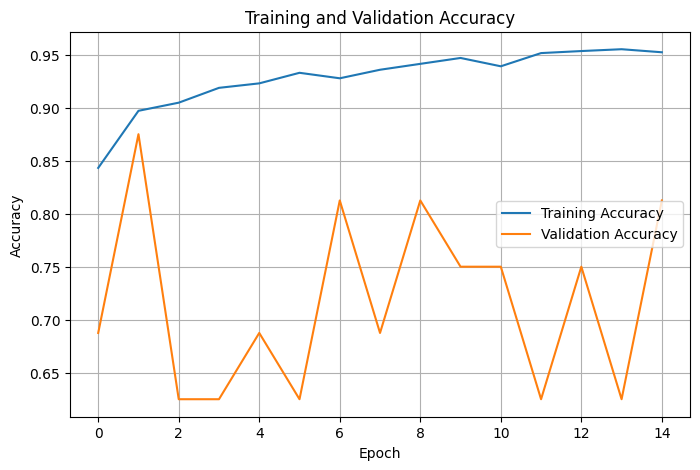

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

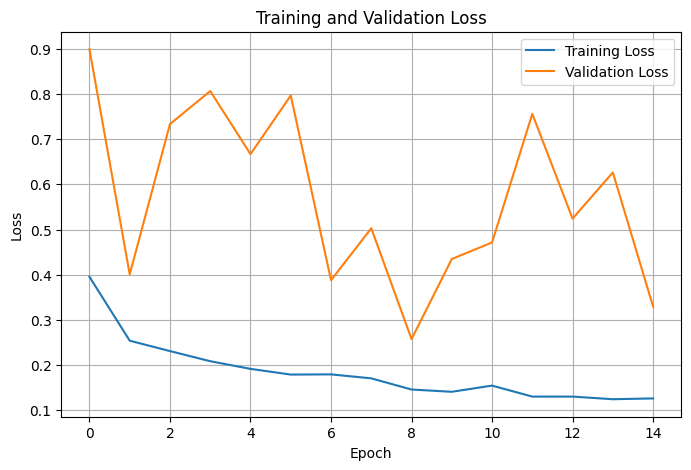

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

In [24]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 248ms/step - accuracy: 0.8301 - loss: 0.4332
Test Loss: 0.43319007754325867
Test Accuracy: 0.8301281929016113


In [25]:
best_model = tf.keras.models.load_model(
    '/content/drive/MyDrive/pneumonia_cnn_best.keras'
)

print("Best model loaded successfully.")

Best model loaded successfully.


In [26]:
best_test_loss, best_test_accuracy = best_model.evaluate(test_generator)

print("Best Model Test Loss:", best_test_loss)
print("Best Model Test Accuracy:", best_test_accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.8189 - loss: 0.4579
Best Model Test Loss: 0.45789337158203125
Best Model Test Accuracy: 0.8189102411270142


In [27]:
test_generator.reset()

y_prob = best_model.predict(test_generator)
y_pred = (y_prob > 0.5).astype(int).ravel()

y_true = test_generator.classes

print("Predictions completed.")
print("Number of predictions:", len(y_pred))

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 245ms/step
Predictions completed.
Number of predictions: 624


In [28]:
report = classification_report(
    y_true,
    y_pred,
    target_names=['NORMAL', 'PNEUMONIA'],
    digits=4
)

print(report)

              precision    recall  f1-score   support

      NORMAL     0.9231    0.5641    0.7003       234
   PNEUMONIA     0.7879    0.9718    0.8703       390

    accuracy                         0.8189       624
   macro avg     0.8555    0.7679    0.7853       624
weighted avg     0.8386    0.8189    0.8065       624



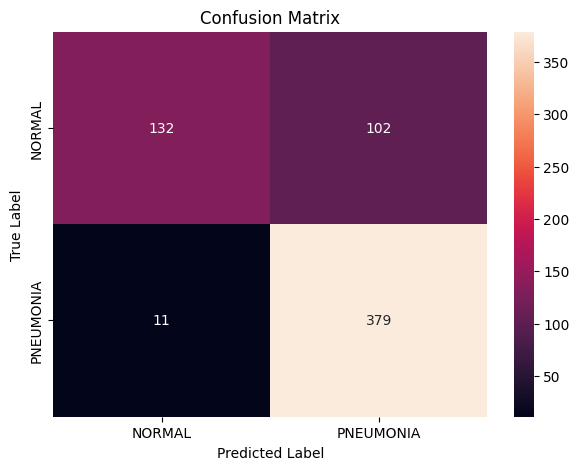

In [29]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['NORMAL', 'PNEUMONIA'],
    yticklabels=['NORMAL', 'PNEUMONIA']
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

plt.show()

In [30]:
accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.8189102564102564
Precision: 0.7879417879417879
Recall   : 0.9717948717948718
F1-Score : 0.870264064293915


In [31]:
final_model_path = '/content/drive/MyDrive/pneumonia_cnn_final.keras'

best_model.save(final_model_path)

print("Final model saved successfully!")
print("Path:", final_model_path)

Final model saved successfully!
Path: /content/drive/MyDrive/pneumonia_cnn_final.keras


In [32]:
print("===== FINAL MODEL INFORMATION =====")
print("Input Size      :", IMG_SIZE)
print("Batch Size      :", BATCH_SIZE)
print("Optimizer       : Adam")
print("Loss Function   : Binary Crossentropy")
print("Epochs          :", EPOCHS)
print("Test Accuracy   :", f"{best_test_accuracy * 100:.2f}%")
print("Test Precision  :", f"{precision * 100:.2f}%")
print("Test Recall     :", f"{recall * 100:.2f}%")
print("Test F1-Score   :", f"{f1 * 100:.2f}%")
print("===================================")

===== FINAL MODEL INFORMATION =====
Input Size      : (224, 224)
Batch Size      : 32
Optimizer       : Adam
Loss Function   : Binary Crossentropy
Epochs          : 15
Test Accuracy   : 81.89%
Test Precision  : 78.79%
Test Recall     : 97.18%
Test F1-Score   : 87.03%


In [33]:
readme_content = """
# Pneumonia Detection Using CNN

## Problem Statement

The objective of this project is to develop a Convolutional Neural Network (CNN)
to classify pediatric chest X-ray images into two classes:

- NORMAL
- PNEUMONIA

## Dataset

The dataset contains pediatric chest X-ray images divided into training,
validation, and testing sets.

The extracted dataset contained:

- Training images: 5,216
- Validation images: 16
- Testing images: 624
- Total valid images: 5,856

The dataset is divided into two classes:

- NORMAL
- PNEUMONIA

The dataset is imbalanced, with more Pneumonia images than Normal images.

## Methodology

The following steps were performed:

1. Loaded the chest X-ray dataset.
2. Resized all images to 224 × 224 pixels.
3. Normalized pixel values to the range [0, 1].
4. Applied data augmentation to the training images.
5. Built a CNN model using convolutional and max-pooling layers.
6. Added fully connected layers for classification.
7. Used Dropout to reduce overfitting.
8. Used Adam optimizer and Binary Crossentropy loss.
9. Trained the model for 15 epochs.
10. Evaluated the model using the test dataset.
11. Generated a classification report and confusion matrix.

## CNN Architecture

The CNN consists of:

- Input layer: 224 × 224 × 3
- Conv2D: 32 filters
- MaxPooling2D
- Conv2D: 64 filters
- MaxPooling2D
- Conv2D: 128 filters
- MaxPooling2D
- Flatten
- Dense: 128 neurons
- Dropout: 0.5
- Output layer: 1 neuron with sigmoid activation

Total trainable parameters: 11,169,089

## Data Augmentation

The following augmentation techniques were applied to training images:

- Rotation
- Width shifting
- Height shifting
- Zoom
- Horizontal flipping

Validation and test images were only normalized and were not augmented.

## Evaluation Metrics

The model was evaluated using:

- Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix

## Results

The final evaluation results on the test dataset are:

| Metric | Score |
|---|---:|
| Accuracy | 81.89% |
| Precision | 78.79% |
| Recall | 97.18% |
| F1-Score | 87.03% |

### Confusion Matrix

| Actual / Predicted | NORMAL | PNEUMONIA |
|---|---:|---:|
| NORMAL | 132 | 102 |
| PNEUMONIA | 11 | 379 |

## Findings

The CNN achieved an overall test accuracy of 81.89%.

The model achieved a high recall of 97.18% for the Pneumonia class,
indicating that it correctly identified most Pneumonia images in the test set.

However, the recall for the Normal class was lower than that of the
Pneumonia class. This is likely influenced by the class imbalance in the
dataset.

Another limitation is that the extracted validation set contained only
16 images, which is very small. Therefore, validation performance may be
unstable and should be interpreted cautiously.

## Model Saving

The trained model was saved in Keras format:

`pneumonia_cnn_final.keras`

## Technologies Used

- Python
- TensorFlow / Keras
- NumPy
- Pandas
- Scikit-learn
- Matplotlib
- Seaborn
- Google Colab

## Conclusion

A CNN-based image classification model was successfully developed for
classifying pediatric chest X-ray images into Normal and Pneumonia classes.
The model achieved an accuracy of 81.89% and an F1-score of 87.03% on the
test dataset.

The results demonstrate that the CNN was able to learn useful visual
patterns from the chest X-ray images. However, the small validation set and
class imbalance are important limitations of this experiment.
"""

with open('/content/README_Problem_Set_01.md', 'w') as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [34]:
with open('/content/README_Problem_Set_01.md', 'r') as f:
    content = f.read()

print(content)


# Pneumonia Detection Using CNN

## Problem Statement

The objective of this project is to develop a Convolutional Neural Network (CNN)
to classify pediatric chest X-ray images into two classes:

- NORMAL
- PNEUMONIA

## Dataset

The dataset contains pediatric chest X-ray images divided into training,
validation, and testing sets.

The extracted dataset contained:

- Training images: 5,216
- Validation images: 16
- Testing images: 624
- Total valid images: 5,856

The dataset is divided into two classes:

- NORMAL
- PNEUMONIA

The dataset is imbalanced, with more Pneumonia images than Normal images.

## Methodology

The following steps were performed:

1. Loaded the chest X-ray dataset.
2. Resized all images to 224 × 224 pixels.
3. Normalized pixel values to the range [0, 1].
4. Applied data augmentation to the training images.
5. Built a CNN model using convolutional and max-pooling layers.
6. Added fully connected layers for classification.
7. Used Dropout to reduce overfitting.
8. U

In [35]:
requirements_content = """tensorflow
numpy
matplotlib
seaborn
scikit-learn
"""

with open('/content/requirements.txt', 'w') as f:
    f.write(requirements_content)

print("requirements.txt created successfully!")

requirements.txt created successfully!


In [36]:
import os
import shutil

shutil.copy(
    '/content/README_Problem_Set_01.md',
    '/content/README.md'
)

print("README.md ready!")
print("Files:")
print(os.path.exists('/content/README.md'))
print(os.path.exists('/content/requirements.txt'))

README.md ready!
Files:
True
True
